# **Feature Engineering**

Feature Engineering is the process of transforming raw data into meaningful input features for Machine Learning models. It improves model performance by enhancing predictive power.

Key Steps in Feature Engineering

✅ Feature Encoding → Convert categorical data into numerical (One-Hot, Label, Target Encoding).

✅ Feature Selection → Identify important features (e.g., using RFE, SelectKBest).

✅ Feature Scaling → Normalize/Standardize numeric data (MinMaxScaler, StandardScaler).

✅ Feature Transformation → Apply log, power, or polynomial transformations to improve distributions.

# **✅Feature Encoding from an ML Model Perspective**

Feature encoding is a crucial step in machine learning as it directly impacts model performance. Let's analyze different encoding techniques from an ML model perspective (POV).

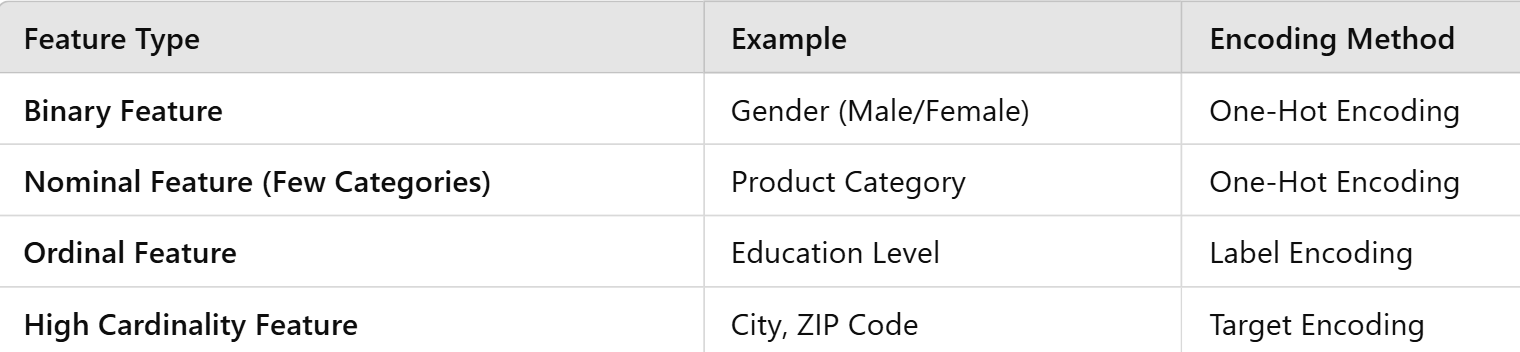

## 1️⃣ **Label Encoding (For Ordered Categories)**

## 📌 Example Feature: "Education" (Primary, Secondary, Tertiary, PhD)

### ✅ Use Case: When categories have a natural order.




In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df = pd.DataFrame({'Education': ['Primary', 'Secondary', 'Tertiary', 'PhD', 'Secondary', 'Tertiary']})

le = LabelEncoder()
df['Education_Encoded'] = le.fit_transform(df['Education'])  # Encode categories into numbers

print(df)


   Education  Education_Encoded
0    Primary                  1
1  Secondary                  2
2   Tertiary                  3
3        PhD                  0
4  Secondary                  2
5   Tertiary                  3


## **2️⃣ One-Hot Encoding (For Nominal Categories)**
### 📌 Example Feature: "Gender" (Male, Female)
### ✅ Use Case: When there are few unordered categories.

In [ ]:

df = pd.DataFrame({'Gender': ['Male', 'Female', 'Female', 'Male', 'Male']})

df

df["Gender"].value_counts()

,count
Gender,
Male,3
Female,2


In [ ]:
df=pd.get_dummies(df["Gender"], dtype=int,drop_first=True)

In [ ]:
df

,Male
0,1
1,0
2,0
3,1
4,1


## **3️⃣ Target Encoding (if target is continueous)/ regression**
### 📌 Example Feature: "City" (100+ Unique Values)
### ✅ Use Case: When there are many categories, and the target is numeric.

In [ ]:
df = pd.DataFrame({
    'City': ['Delhi', 'Mumbai', 'Chennai', 'Delhi', 'Mumbai', 'Chennai'],
    'House_Price': [5000, 7000, 6000, 5200, 7100, 5900]  # Target variable
})
df["City"].value_counts()

,count
City,
Delhi,2
Mumbai,2
Chennai,2


In [ ]:
df = pd.DataFrame({
    'City': ['Delhi', 'Mumbai', 'Chennai', 'Delhi', 'Mumbai', 'Chennai'],
    'House_Price': [5000, 7000, 6000, 5200, 7100, 5900]  # Target variable
})

df['City_Encoded'] = df.groupby('City')['House_Price'].transform('mean')

print(df)


      City  House_Price  City_Encoded
0    Delhi         5000        5100.0
1   Mumbai         7000        7050.0
2  Chennai         6000        5950.0
3    Delhi         5200        5100.0
4   Mumbai         7100        7050.0
5  Chennai         5900        5950.0


## **3️⃣ Target Encoding (if target is discreate)/ classification**
### 📌 Example Feature: "City" (100+ Unique Values)
### ✅ Use Case: When there are many categories, and the target is disrete.

In [ ]:
import pandas as pd

# Sample dataset
df = pd.DataFrame({
    'City': ['Delhi', 'Mumbai', 'Chennai', 'Delhi', 'Mumbai', 'Chennai', 'Delhi', 'Mumbai'],
    'Polluted': ['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes']  # Categorical Target
})


# Compute probability of the most frequent class for each City
prob_encoding = df.groupby('City')['Polluted'].apply(lambda x: x.value_counts(normalize=True).max())

# Map the probability encoding back to the dataset
df['City_Encoded'] = df['City'].map(prob_encoding)

print(df)


      City Polluted  City_Encoded
0    Delhi      Yes      1.000000
1   Mumbai       No      0.666667
2  Chennai      Yes      0.500000
3    Delhi      Yes      1.000000
4   Mumbai       No      0.666667
5  Chennai       No      0.500000
6    Delhi      Yes      1.000000
7   Mumbai      Yes      0.666667


# ✅ **Feature Selection in Machine Learning**
Feature selection is the process of choosing the most relevant features (independent variables) for a machine learning model. It helps improve model accuracy, reduce overfitting, and speed up training by eliminating irrelevant or redundant features.


✅ Why use Feature Selection?  
✔️ Reduces Overfitting – Removes irrelevant features to prevent the model from learning noise.  
✔️ Improves Accuracy – Focuses on the most important features.  
✔️ Speeds up Training – Reduces computational cost by eliminating unnecessary variables.  
⭕

📌 Feature Selection Methods

# **🏷️ Method 1: Select K Best using Cross-Validation (CV)**

📖 Description: Uses cross-validation to find the optimal number of features (k) and then selects the top k best features.  
🔍 Steps:  
1️⃣ Perform cross-validation with different values of k.  
2️⃣ Select k that gives the best model performance.  
3️⃣ Use SelectKBest to choose the k best features.  
✅ Pros:  
✔️ Simple to implement.  
✔️ Works well for feature ranking.  
✔️ Helps in dimensionality reduction.  
❌ Cons:  
❌ Requires manual selection of k.  
❌ May not capture feature interactions.  






In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
feature_names #column names


array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape

(455, 30)

In [ ]:
# Trying different values of k
k_values = range(1, X.shape[1] + 1)  # From 1 to 31
best_score = 0
best_k = 1

for k in k_values:
    # Select K Best features
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Train the model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_selected, y_train)

    # Evaluate the model
    y_pred = model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)

    if accuracy > best_score:
        best_score = accuracy
        best_k = k
        best_features = selector.get_support()

print(f"✅ Best k: {best_k} with accuracy: {best_score:.4f}")

✅ Best k: 16 with accuracy: 0.9649


In [ ]:
# Final feature selection with best k
final_selector = SelectKBest(score_func=f_classif, k=16)
X_selected = final_selector.fit_transform(X, y)

# Get selected feature names
selected_features = feature_names[final_selector.get_support()]
print(f"🎯 Selected Features ({best_k}): {selected_features}")

🎯 Selected Features (16): ['mean radius' 'mean perimeter' 'mean area' 'mean compactness'
 'mean concavity' 'mean concave points' 'radius error' 'perimeter error'
 'area error' 'worst radius' 'worst texture' 'worst perimeter'
 'worst area' 'worst compactness' 'worst concavity' 'worst concave points']


In [ ]:
import pandas as pd

# Convert dataset to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Select only the best features
X_selected_df = df[selected_features]

# Display the first few rows
X_selected_df.head()


,mean radius,mean perimeter,mean area,mean compactness,mean concavity,mean concave points,radius error,perimeter error,area error,worst radius,worst texture,worst perimeter,worst area,worst compactness,worst concavity,worst concave points
0,17.99,122.80,1001.0,0.27760,0.3001,0.14710,1.0950,8.589,153.40,25.38,17.33,184.60,2019.0,0.6656,0.7119,0.2654
1,20.57,132.90,1326.0,0.07864,0.0869,0.07017,0.5435,3.398,74.08,24.99,23.41,158.80,1956.0,0.1866,0.2416,0.1860
2,19.69,130.00,1203.0,0.15990,0.1974,0.12790,0.7456,4.585,94.03,23.57,25.53,152.50,1709.0,0.4245,0.4504,0.2430
3,11.42,77.58,386.1,0.28390,0.2414,0.10520,0.4956,3.445,27.23,14.91,26.50,98.87,567.7,0.8663,0.6869,0.2575
4,20.29,135.10,1297.0,0.13280,0.1980,0.10430,0.7572,5.438,94.44,22.54,16.67,152.20,1575.0,0.2050,0.4000,0.1625


#  **🏷️ Method 2: Feature Selection Using Random Forest**

## 📖 Description:  
Random Forest is an ensemble learning method that provides built-in feature importance based on how much a feature contributes to reducing impurity (Gini or MSE).  

## 🔍 Steps to Perform Feature Selection:  
1️⃣ Train a Random Forest model on the dataset.  
2️⃣ Extract feature importance scores from the trained model.  
3️⃣ Rank features by importance.  
4️⃣ Select the top K most important features based on a threshold.  

## ✅ Pros:  
✔️ Handles non-linearity and complex feature interactions.  
✔️ Works well with high-dimensional data.  
✔️ Fast & scalable compared to wrapper methods.  
✔️ No need for additional feature selection techniques.  

## ❌ Cons:  
❌ Doesn’t remove redundant features (some features may be correlated).  
❌ Sensitive to noise if the dataset is not cleaned properly.  


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)

# Print sorted feature importance
print("🔹 **Feature Importance (High to Low):**")
print(feature_importance.sort_values(ascending=False))


🔹 **Feature Importance (High to Low):**
worst area                 0.153892
worst concave points       0.144663
mean concave points        0.106210
worst radius               0.077987
mean concavity             0.068001
worst perimeter            0.067115
mean perimeter             0.053270
mean radius                0.048703
mean area                  0.047555
worst concavity            0.031802
area error                 0.022407
worst texture              0.021749
worst compactness          0.020266
radius error               0.020139
mean compactness           0.013944
mean texture               0.013591
perimeter error            0.011303
worst smoothness           0.010644
worst symmetry             0.010120
concavity error            0.009386
mean smoothness            0.007285
fractal dimension error    0.005321
compactness error          0.005253
worst fractal dimension    0.005210
texture error              0.004724
smoothness error           0.004271
symmetry error          

In [ ]:
# Select features with importance > 0.01
selected_features = feature_importance[feature_importance > 0.01].index
X_selected = X[selected_features]

# Print selected features
print("🔹 Selected Features (Importance > 0.01):")
print(selected_features)

🔹 Selected Features (Importance > 0.01):
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean compactness', 'mean concavity', 'mean concave points',
       'radius error', 'perimeter error', 'area error', 'worst radius',
       'worst texture', 'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry'],
      dtype='object')


In [ ]:
len(selected_features)

19

# 📊 Comparison: Random Forest vs. SelectKBest (CV)  

| Feature Selection Method | **Random Forest Feature Importance** 🌲 | **SelectKBest (Cross-Validation)** 🎯 |
|-------------------------|--------------------------------|----------------------------------|
| **Description** | Uses Random Forest to compute feature importance scores. | Uses statistical tests to select top K features with the highest scores. |
| **Feature Selection Criteria** | Selects features based on importance scores (> threshold, e.g., 0.01). | Selects the top K features based on statistical scores. |
| **Feature Interactions** | ✅ Considers feature interactions. | ❌ Does not consider feature interactions. |
| **Model Dependency** | ❌ Model-dependent (Random Forest). | ✅ Independent of any ML model. |
| **Ease of Implementation** | ✅ Easy to implement, but requires setting a threshold. | ✅ Easy to implement, but requires choosing K. |
| **Redundant Features** | ❌ May not remove redundant features. | ✅ Helps remove irrelevant features. |
| **Computational Efficiency** | ✅ Fast & scalable. | ✅ Fast, but K needs to be optimized. |
| **Best Use Cases** | When working with large datasets & non-linear relationships. | When a simpler statistical selection method is preferred. |

